In [1]:
'''
    @Author: Dhananjay Kumar
    @Date: 05-01-2025
    @Last Modified by: Dhananjay Kumar
    @Last Modified time: 05-01-2025
    @Title : Linear Regression implementation from scratch
'''

'\n    @Author: Dhananjay Kumar\n    @Date: 05-01-2025\n    @Last Modified by: Dhananjay Kumar\n    @Last Modified time: 05-01-2025\n    @Title : Linear Regression implementation from scratch\n'

## Importing Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.axes as ax

## Loading Data

In [3]:
data = pd.read_csv('data_for_lr.csv')

**data exploration**

In [4]:
data.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       700 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 11.1 KB


## Data Preprocessing

#### Handling NULL Value

In [6]:
data.isnull().sum()

x    0
y    1
dtype: int64

In [7]:
data.shape

(700, 2)

In [8]:
data = data.dropna()
print("Shape of the dataset = {}".format(data.shape))

Shape of the dataset = (699, 2)


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 699 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       699 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 16.4 KB


## scaling

In [10]:
num_columns = [col for col in data.columns if data[col].dtype != object]

In [11]:
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()

In [12]:
#data[num_columns] = scaler.fit_transform(data[num_columns])

In [13]:
data.head()

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984


#### Splitting data

In [14]:
# training dataset and labels
train_input = np.array(data.x[0:500]).reshape(500,1)
train_output  = np.array(data.y[0:500]).reshape(500,1)

# valid dataset and labels
test_input = np.array(data.x[500:700]).reshape(199,1)
test_output  = np.array(data.y[500:700]).reshape(199,1)

# print the shapes
print("Train Input Shape = {}".format(train_output.shape))
print("Train Output  Shape = {}".format(train_output.shape))
print("Test Input Shape = {}".format(test_input.shape))
print("Test Output  Shape = {}".format(test_output.shape))

Train Input Shape = (500, 1)
Train Output  Shape = (500, 1)
Test Input Shape = (199, 1)
Test Output  Shape = (199, 1)


# <font color = "green">Gradient Descent using Linear Regression</font>

## Forward Propogation

Here's how **Forward Propagation** looks with your requested format:

---

## 1. Forward Propagation
In linear regression, forward propagation calculates the predicted values (\( ŷ \)) based on the input feature (\( x \)) and the model's parameters (\( m \) and \( c \)).

**Equation**:  
-            f(x) = m*x + c

Where:
- \( x \): Input feature (independent variable).
- \( m \): Weight (slope or coefficient).
- \( c \): Bias (intercept).
- \( f(x) \): Predicted output (dependent variable).

During training, the model learns the values of \( m \) and \( c \) to minimize the prediction error.
**f(x) = m*x + c** ; 

where m and c are the parameters that or model will learn through training.

In [15]:
def forward_propagation(train_input, parameters):
    m = parameters['m']
    c = parameters['c']
    predictions = np.multiply(m, train_input) + c
    return predictions

## Defining Cost Function

## 2. Cost Function

**Mean Squared Error, Cost = [(y - f(x)) ^ 2] * 0.5**


The cost function measures the difference between the true values (\( y \)) and the predicted values (\( f(x) \)). In linear regression, we use the **Mean Squared Error (MSE)** as the cost function.

**Equation**:  

**Cost = [(yᵢ - f(xᵢ))²] / (2 * m)**

Or for a single data point:
**Cost = [(y - f(x))²] / 2**

**Simplified Format**:  
\[
**Cost = [(yᵢ - f(xᵢ))²] / (2 * m)**
\]

Where:
- \( y \): Actual or true value.
- \( f(x) \): Predicted value from the model (\( f(x) = m*x + c \)).
- \( m \): Total number of data points.  

The cost represents the error, and the goal is to minimize it during training.

where y are the actual or true values and f(x) are the predicted values.

In [16]:
def cost_function(predictions, train_output):
    cost = np.mean((train_output - predictions) ** 2) * 0.5
    return cost

## Gradient Descent for Backpropagation

<u>Using Chain Rule:</u>
- cost
- f = f(x)

Partial Derivative of cost function w.r.t m 
**dcost/dm = dcost/df * df/dm **

Partial Derivative of cost function w.r.t c
**dcost/dc = dcost/df * df/dc **

<u>Partial Derivatives:</u>
- dc/df = (y - f) * -1
- df/dw = x
- df/db = 1

In [17]:
def backward_propagation(train_input, train_output, predictions):
    derivatives = dict()
    df = (train_output - predictions) * -1
    dm = np.mean(np.multiply(train_input, df))
    dc = np.mean(df)
    derivatives['dm'] = dm
    derivatives['dc'] = dc
    return derivatives

## Update the Parameters

- m = m - (learning_rate * dm)
- c = c - (learning_rate * dc)

In [18]:
def update_parameters(parameters, derivatives, learning_rate):
    parameters['m'] = parameters['m'] - learning_rate * derivatives['dm']
    parameters['c'] = parameters['c'] - learning_rate * derivatives['dc']
    return parameters

## Train the Data

Sequence of Steps:

- Forward Propagtaion
- Cost Function
- Backward Propagation
- Update Parameters

In [19]:
def train(train_input, train_output, learning_rate, iters):
    
    #random parameters
    parameters = dict()
    parameters["m"] = np.random.uniform(0,1) * -1
    parameters["c"] = np.random.uniform(0,1) * -1
    
    plt.figure()
    
    #loss
    loss = list()
    
    #iterate
    for i in range(iters):
        
        #forward propagation
        predictions = forward_propagation(train_input, parameters)
        
        #cost function
        cost = cost_function(predictions, train_output)
        
        #append loss and print
        loss.append(cost)
        print("Iteration = {}, Loss = {}".format(i+1, cost))
        
        #plot function
        fig, ax = plt.subplots()
        
        ax.plot(train_input, train_output, '+', label='Original')
        ax.plot(train_input, predictions, '*', label='Training')

        legend = ax.legend()
        
        plt.plot(train_input, train_output, '+')
        plt.plot(train_input, predictions, '*')        
        
        plt.show()
        
        #back propagation
        derivatives = backward_propagation(train_input, train_output, predictions)
        
        #update parameters
        parameters = update_parameters(parameters, derivatives, learning_rate)
        
    return parameters, loss

## Training

Iteration = 1, Loss = 4098.569236914858


<Figure size 640x480 with 0 Axes>

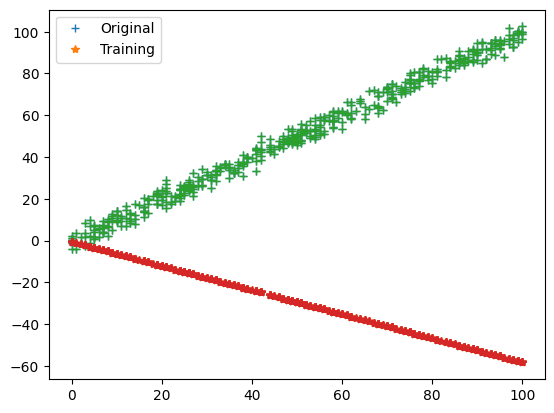

Iteration = 2, Loss = 1861.6688380850476


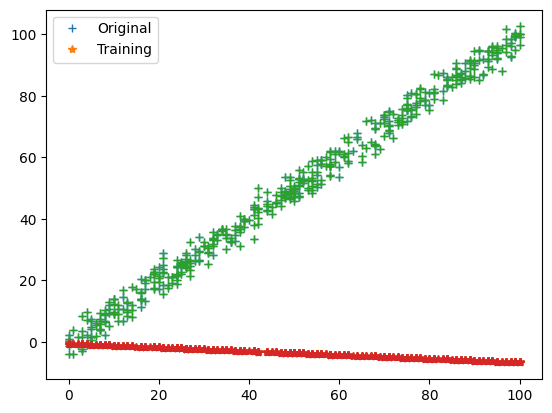

Iteration = 3, Loss = 846.7846490896952


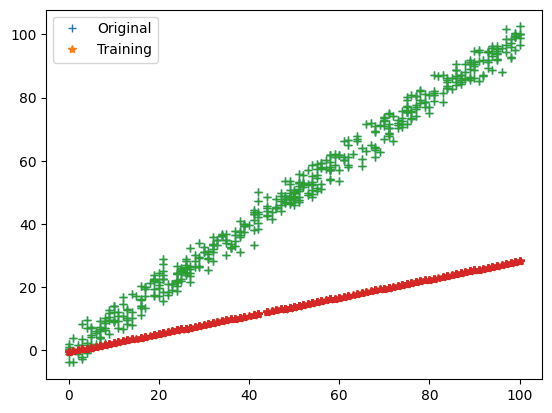

Iteration = 4, Loss = 386.3305680517727


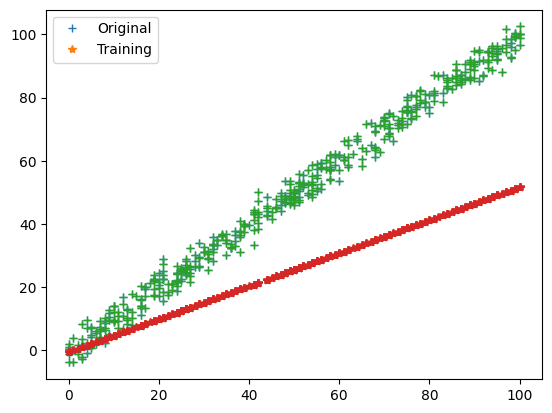

Iteration = 5, Loss = 177.42204110379237


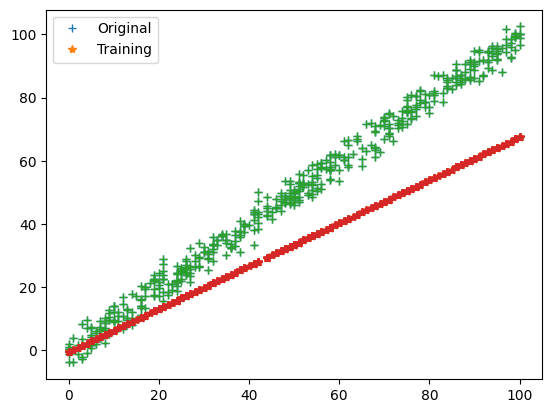

Iteration = 6, Loss = 82.64001066866011


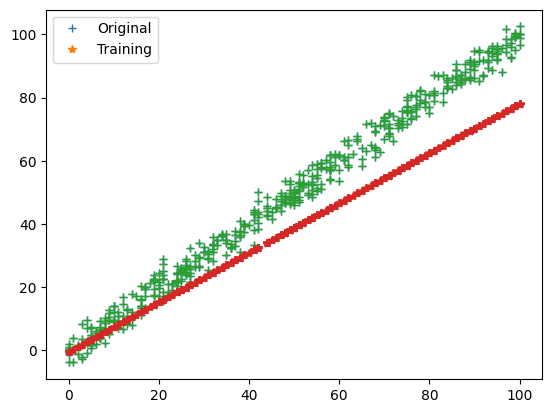

Iteration = 7, Loss = 39.63729811263645


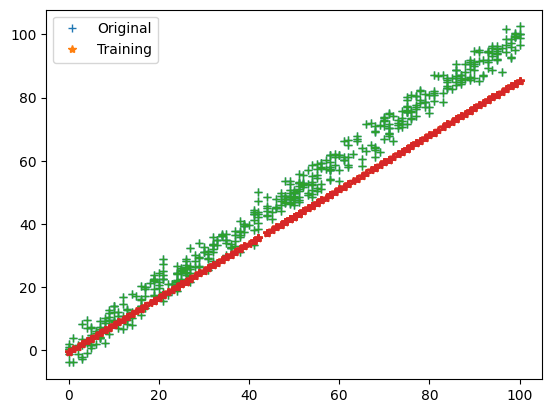

Iteration = 8, Loss = 20.126919431289156


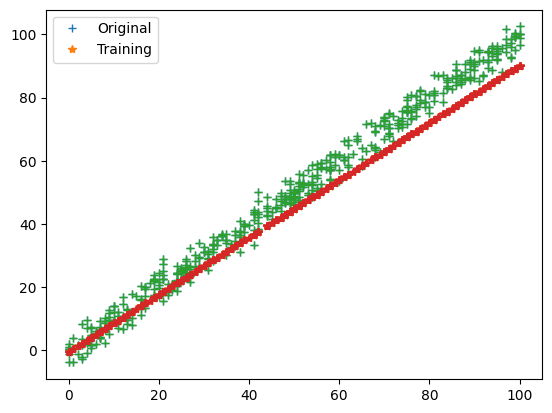

Iteration = 9, Loss = 11.275038649978063


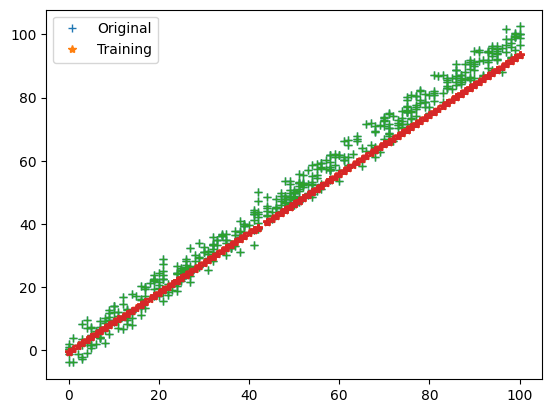

Iteration = 10, Loss = 7.25893017172322


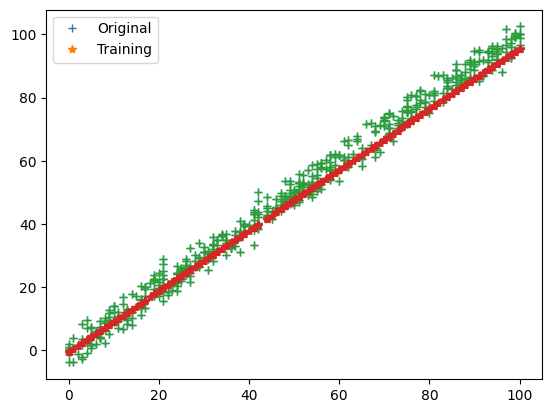

In [20]:
parameters, loss = train(train_input, train_output, 0.0001, 10)

In [21]:
print(parameters)

{'m': 0.9754534191867457, 'c': -0.5601204015937763}


## Let's Predict

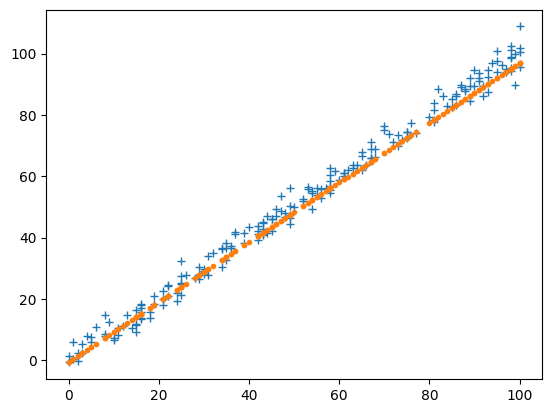

In [22]:
test_predictions = test_input * parameters["m"] + parameters["c"]
plt.figure()
plt.plot(test_input, test_output, '+')
plt.plot(test_input, test_predictions, '.')
plt.show()

## Cost for test data

In [23]:
cost_function(test_predictions, test_output)*2

12.4946585298704

In [24]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [25]:
model.fit(train_input,train_output)

LinearRegression()

In [26]:
y_pred = model.predict(test_input)

In [27]:
from sklearn.metrics import mean_squared_error
error = mean_squared_error(y_pred,test_output)

In [28]:
print("error : ",error)

error :  8.030031591835375
